# Punto 4: Motor de Recomendación de Productos en Tiempo Real

**Objetivo:** Diseñar la arquitectura y el flujo lógico de un servicio de recomendación automatizado en tiempo real, activado cuando un cliente visita el sitio web.

## Decisión de Alcance (Importante)

Para esta evaluación, el entregable principal es **diseño de sistema + lógica de decisión**.  
Este notebook incluye un **prototipo ligero** únicamente para demostrar que el flujo es ejecutable de extremo a extremo.

- **No** es una implementación de recomendador para producción.
- Demuestra enrutamiento, señales de ranking y personalización consciente del segmento.
- Las consideraciones de producción (recuperación distribuida, índices ANN, SLAs de frescura de features, observabilidad) se describen en la sección de arquitectura.

---
## 1. Configuración y Preparación de Datos

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from scipy.sparse import csr_matrix
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'danger': '#C73E1D', 'success': '#27AE60', 'neutral': '#3B1F2B'
}

DATA_PATH = '../Dataset_prueba/'

customers = pd.read_csv(f'{DATA_PATH}customers_dataset.csv')
orders = pd.read_csv(f'{DATA_PATH}orders_dataset.csv')
order_items = pd.read_csv(f'{DATA_PATH}order_items_dataset.csv')
order_payments = pd.read_csv(f'{DATA_PATH}order_payments_dataset.csv')
reviews = pd.read_csv(f'{DATA_PATH}order_reviews_dataset.csv')
products = pd.read_csv(f'{DATA_PATH}products_dataset.csv')
categories = pd.read_csv(f'{DATA_PATH}product_category_name_translation.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered = delivered.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')

# Construir tabla unificada de ventas
sales = (
    order_items
    .merge(delivered[['order_id', 'customer_unique_id', 'order_purchase_timestamp']], on='order_id')
    .merge(products, on='product_id', how='left')
    .merge(categories, on='product_category_name', how='left')
)
sales['category'] = sales['product_category_name_english'].fillna('uncategorized')

print(f'Sales records: {len(sales):,}')
print(f'Unique products sold: {sales["product_id"].nunique():,}')
print(f'Unique customers: {sales["customer_unique_id"].nunique():,}')
print(f'Unique categories: {sales["category"].nunique()}')

Sales records: 110,197
Unique products sold: 32,216
Unique customers: 93,358
Unique categories: 72


---
## 2. Nivel 1 — Arranque en Frío: Rankings de Popularidad y Categoría

Para visitantes nuevos/anónimos, recomendamos basándonos en **lo que está en tendencia** — global y por categoría. Este es el respaldo que garantiza que cada visitante reciba sugerencias relevantes.

In [31]:
# --- Puntajes de popularidad: combinando volumen, ingresos y recencia ---
REFERENCE_DATE = sales['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

product_popularity = sales.groupby('product_id').agg(
    units_sold=('order_item_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    unique_buyers=('customer_unique_id', 'nunique'),
    last_sold=('order_purchase_timestamp', 'max'),
    category=('category', 'first')
).reset_index()

# Peso de recencia: productos vendidos recientemente reciben impulso
product_popularity['days_since_last_sale'] = (REFERENCE_DATE - product_popularity['last_sold']).dt.days
product_popularity['recency_weight'] = np.exp(-product_popularity['days_since_last_sale'] / 180)  # 6-month decay

# Puntaje compuesto de popularidad
scaler = MinMaxScaler()
for col in ['units_sold', 'unique_buyers', 'total_revenue']:
    product_popularity[f'{col}_norm'] = scaler.fit_transform(product_popularity[[col]])

product_popularity['popularity_score'] = (
    0.35 * product_popularity['units_sold_norm'] +
    0.30 * product_popularity['unique_buyers_norm'] +
    0.20 * product_popularity['total_revenue_norm'] +
    0.15 * product_popularity['recency_weight']
).round(4)

# Top productos por popularidad
top_popular = product_popularity.sort_values('popularity_score', ascending=False).head(10)
print('🔥 TOP 10 PRODUCTS BY COMPOSITE POPULARITY SCORE')
print('=' * 85)
print(top_popular[['product_id', 'category', 'units_sold', 'unique_buyers', 
                     'avg_price', 'popularity_score']].to_string(
    index=False, formatters={'avg_price': 'R$ {:.0f}'.format}
))

# Popularidad a nivel de categoría (para recomendaciones de navegación)
category_popularity = product_popularity.groupby('category').agg(
    total_products=('product_id', 'count'),
    total_units=('units_sold', 'sum'),
    avg_popularity=('popularity_score', 'mean'),
    top_product_score=('popularity_score', 'max')
).sort_values('total_units', ascending=False)

print(f'\n📊 Top 10 Categories by Total Units')
print(category_popularity.head(10)[['total_units', 'total_products', 'avg_popularity']].to_string())

🔥 TOP 10 PRODUCTS BY COMPOSITE POPULARITY SCORE
                      product_id              category  units_sold  unique_buyers avg_price  popularity_score
99a4788cb24856965c36a24e339b6058        bed_bath_table         477            456     R$ 88            0.8952
aca2eb7d00ea1a7b8ebd4e68314663af       furniture_decor         520            424     R$ 71            0.8868
422879e10f46682990de24d770e7f83d          garden_tools         484            349     R$ 55            0.7760
d1c427060a0f73f6b889a5c7c61f2ac4 computers_accessories         332            312    R$ 137            0.7161
389d119b48cf3043d311335e499d9c6b          garden_tools         390            308     R$ 55            0.6714
368c6c730842d78016ad823897a372db          garden_tools         388            289     R$ 54            0.6638
53b36df67ebb7c41585e8d54d6772e08         watches_gifts         321            301    R$ 117            0.6598
53759a2ecddad2bb87a079a1f1519f73          garden_tools         373      

---
## 3. Nivel 2 — Filtrado Basado en Contenido: Similitud de Productos

Para clientes con al menos una compra, recomendamos productos similares basándonos en **características del producto**. Esto aborda el problema de arranque en frío aprovechando metadata del producto en lugar del historial del usuario.

In [32]:
# --- Construir matriz de features de producto ---
# Features: categoría (one-hot), rango de precio, atributos físicos, puntajes de reseña

# Reseña promedio por producto
product_reviews = (
    reviews.merge(order_items[['order_id', 'product_id']], on='order_id')
    .groupby('product_id')['review_score'].agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_review', 'count': 'review_count'})
)

# Unir features de producto
product_features = products.merge(categories, on='product_category_name', how='left')
product_features['category'] = product_features['product_category_name_english'].fillna('uncategorized')
product_features = product_features.merge(product_reviews, on='product_id', how='left')
product_features = product_features.merge(
    product_popularity[['product_id', 'avg_price', 'popularity_score']], on='product_id', how='left'
)

# Rellenar nulos
product_features['avg_review'] = product_features['avg_review'].fillna(product_features['avg_review'].median())
product_features['review_count'] = product_features['review_count'].fillna(0)
product_features['popularity_score'] = product_features['popularity_score'].fillna(0)
product_features['avg_price'] = product_features['avg_price'].fillna(product_features['avg_price'].median())

# Solo mantener productos que han sido vendidos
sold_products = product_popularity['product_id'].unique()
pf = product_features[product_features['product_id'].isin(sold_products)].copy()
pf = pf.set_index('product_id')

# One-hot encode categories
cat_dummies = pd.get_dummies(pf['category'], prefix='cat')

# Features numéricas (normalizar)
num_features = ['avg_price', 'product_weight_g', 'avg_review', 'popularity_score']
pf_num = pf[num_features].fillna(0)
scaler = StandardScaler()
pf_num_scaled = pd.DataFrame(
    scaler.fit_transform(pf_num), index=pf_num.index, columns=pf_num.columns
)

# Combinar: numéricas + dummies de categoría
feature_matrix = pd.concat([pf_num_scaled, cat_dummies], axis=1).fillna(0)

print(f'Product feature matrix: {feature_matrix.shape[0]:,} products × {feature_matrix.shape[1]} features')
print(f'  - {len(num_features)} numerical features')
print(f'  - {len(cat_dummies.columns)} category dummies')

Product feature matrix: 32,216 products × 76 features
  - 4 numerical features
  - 72 category dummies


In [33]:
# --- Similitud de contenido (seguro para prototipo: scoring bajo demanda, sin matriz NxN completa) ---

feature_values = feature_matrix.astype(float).values
feature_index = feature_matrix.index
product_to_pos = {pid: i for i, pid in enumerate(feature_index)}
feature_norms = np.linalg.norm(feature_values, axis=1) + 1e-12


def _content_similarity_scores(product_id: str) -> pd.Series:
    """Cosine similarity against all products for one source product."""
    if product_id not in product_to_pos:
        return pd.Series(dtype=float)

    i = product_to_pos[product_id]
    q = feature_values[i]
    q_norm = feature_norms[i]
    sims = feature_values @ q / (feature_norms * q_norm)
    scores = pd.Series(sims, index=feature_index).drop(product_id)
    return scores.sort_values(ascending=False)


def get_content_recommendations(product_id: str, top_n: int = 5, mode: str = 'all') -> pd.DataFrame:
    """
    mode:
      - 'all'  : overall similar products
      - 'same' : same-category similar products
      - 'cross': cross-category similar products
    """
    if product_id not in feature_index:
        return pd.DataFrame()

    sims = _content_similarity_scores(product_id)
    source_cat = pf.loc[product_id, 'category']

    if mode == 'same':
        sims = sims[pf.loc[sims.index, 'category'] == source_cat]
    elif mode == 'cross':
        sims = sims[pf.loc[sims.index, 'category'] != source_cat]

    top_similar = sims.head(top_n)
    result = pf.loc[top_similar.index, ['category', 'avg_price', 'avg_review']].copy()
    result['similarity'] = top_similar.values
    return result


# Demo: recomendaciones para el producto más vendido
demo_product = top_popular.iloc[0]['product_id']
demo_cat = top_popular.iloc[0]['category']
print(f' Recommendations for product {demo_product[:12]}... (Category: {demo_cat})')
print('')
print('--- Same category ("More like this") ---')
print(get_content_recommendations(demo_product, 5, mode='same').to_string(
    formatters={'avg_price': 'R$ {:.0f}'.format, 'similarity': '{:.3f}'.format}
))
print('')
print('--- Cross-category ("You might also like") ---')
print(get_content_recommendations(demo_product, 5, mode='cross').to_string(
    formatters={'avg_price': 'R$ {:.0f}'.format, 'similarity': '{:.3f}'.format}
))

 Recommendations for product 99a4788cb248... (Category: bed_bath_table)

--- Same category ("More like this") ---
                                        category avg_price  avg_review similarity
product_id                                                                       
06edb72f1e0c64b14c5b79353f7abea3  bed_bath_table     R$ 41    3.993151      0.988
ec2d43cc59763ec91694573b31f1c29a  bed_bath_table     R$ 46    4.069231      0.986
777d2e438a1b645f3aec9bd57e92672c  bed_bath_table     R$ 70    4.052632      0.981
84f456958365164420cfc80fbe4c7fab  bed_bath_table     R$ 93    3.299065      0.980
64fb265487de2238627ce43fe8a67efc  bed_bath_table     R$ 91    3.891892      0.978

--- Cross-category ("You might also like") ---
                                         category avg_price  avg_review similarity
product_id                                                                        
aca2eb7d00ea1a7b8ebd4e68314663af  furniture_decor     R$ 71    4.019084      0.996
422879e10f46682

---
## 4. Nivel 3 — Señal de Co-Compra: Patrones de Co-Compra

Para el ~3% de clientes recurrentes (y para enriquecer las recomendaciones de compra única), analizamos qué productos se compran frecuentemente juntos. Nota: esto es frecuencia de co-compra de ítems, no filtrado colaborativo verdadero (que requeriría una matriz de interacción usuario-ítem).

In [34]:
# --- Análisis de co-compra ---

multi_item_orders = sales.groupby('order_id').filter(lambda x: len(x) > 1)
print(f'Multi-item orders: {multi_item_orders["order_id"].nunique():,} ({multi_item_orders["order_id"].nunique()/sales["order_id"].nunique()*100:.1f}% of orders)')

# Construir pares canónicos (no dirigidos) para evitar duplicación A-B / B-A
pair_counter = defaultdict(int)
for _, group in multi_item_orders.groupby('order_id'):
    products_in_order = sorted(set(group['product_id']))
    for i in range(len(products_in_order)):
        for j in range(i + 1, len(products_in_order)):
            pair_counter[(products_in_order[i], products_in_order[j])] += 1

pair_counts = pd.DataFrame(
    [(a, b, c) for (a, b), c in pair_counter.items()],
    columns=['product_a', 'product_b', 'co_count']
).sort_values('co_count', ascending=False)

print(f'Co-purchase unique pairs: {len(pair_counts):,}')

pair_enriched = pair_counts.merge(
    pf[['category']].rename(columns={'category': 'cat_a'}), left_on='product_a', right_index=True, how='left'
).merge(
    pf[['category']].rename(columns={'category': 'cat_b'}), left_on='product_b', right_index=True, how='left'
)
pair_enriched['cross_category'] = pair_enriched['cat_a'] != pair_enriched['cat_b']

# Lookup dirigido para generación de candidatos de co-compra
directed_pairs = pd.concat([
    pair_counts.rename(columns={'product_a': 'source_product', 'product_b': 'candidate_product'}),
    pair_counts.rename(columns={'product_b': 'source_product', 'product_a': 'candidate_product'})
], ignore_index=True)

copurchase_lookup = {
    pid: grp.set_index('candidate_product')['co_count'].sort_values(ascending=False)
    for pid, grp in directed_pairs.groupby('source_product')
}

print('')
print('🛒 TOP 10 CO-PURCHASE PAIRS')
print(pair_enriched.head(10)[['product_a', 'product_b', 'co_count', 'cat_a', 'cat_b', 'cross_category']].to_string(
    index=False, formatters={'product_a': lambda x: x[:12] + '...', 'product_b': lambda x: x[:12] + '...'}
))

Multi-item orders: 9,635 (10.0% of orders)
Co-purchase unique pairs: 4,022

🛒 TOP 10 CO-PURCHASE PAIRS
      product_a       product_b  co_count                 cat_a                 cat_b  cross_category
36f60d45225e... e53e557d5a15...        34 computers_accessories computers_accessories           False
35afc973633a... 99a4788cb248...        29          home_confort        bed_bath_table            True
4fcb3d9a5f48... f4f67ccaece9...        17                  auto                  auto           False
36f60d45225e... 3f14d740544f...        12 computers_accessories computers_accessories           False
389d119b48cf... 422879e10f46...        11          garden_tools          garden_tools           False
389d119b48cf... 53759a2ecdda...         9          garden_tools          garden_tools           False
368c6c730842... 53759a2ecdda...         8          garden_tools          garden_tools           False
422879e10f46... 53759a2ecdda...         7          garden_tools          garden_t

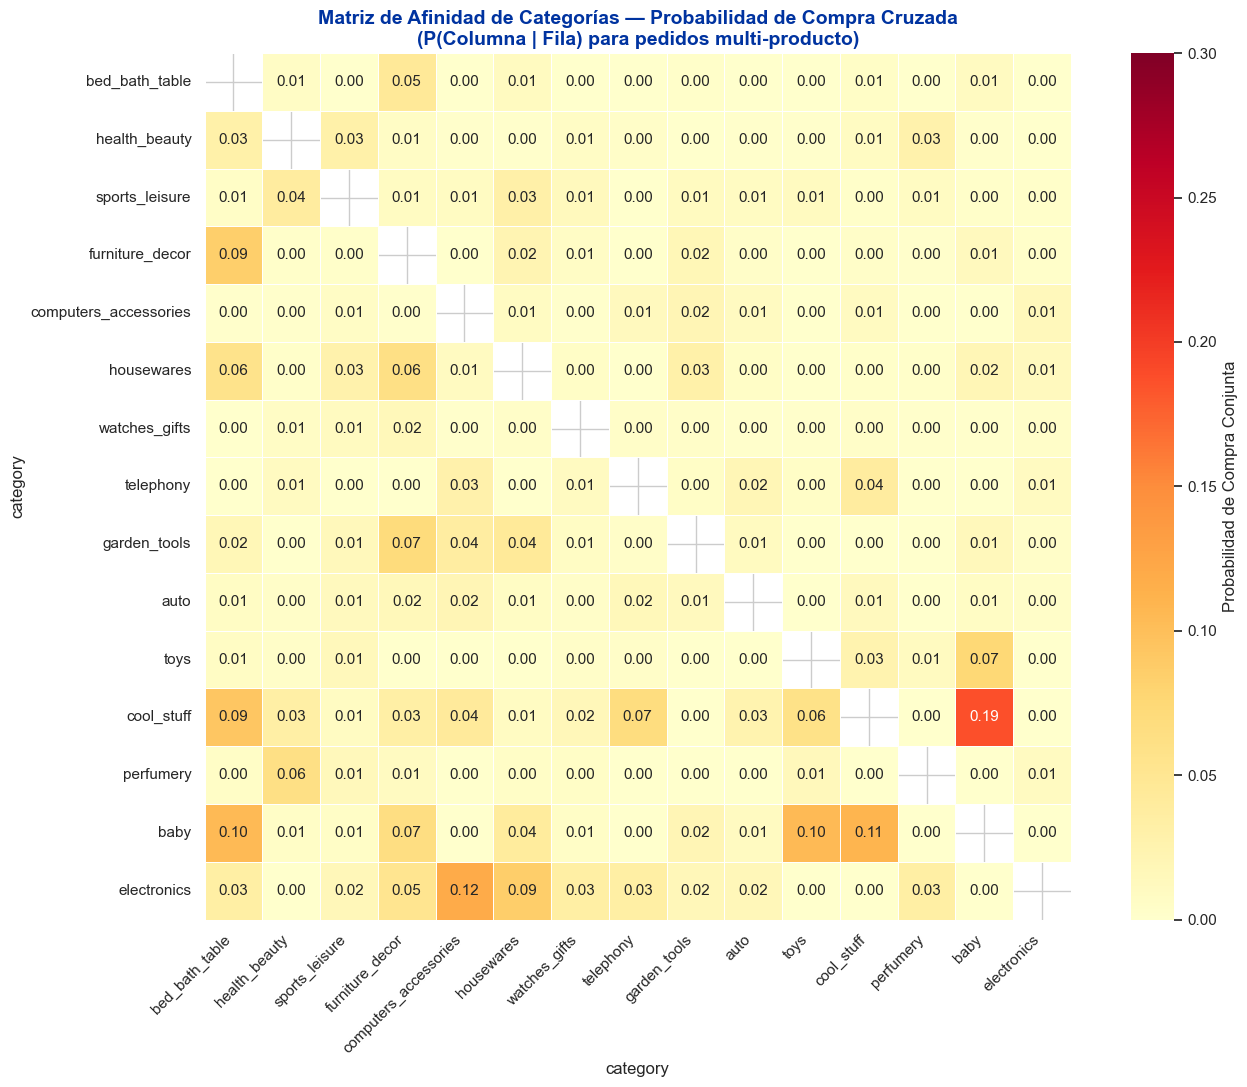

In [35]:
# --- Matriz de Afinidad de Categorías ---
# ¿Qué categorías se compran juntas? (a nivel de pedido)
category_pairs = pair_enriched.groupby(['cat_a', 'cat_b'])['co_count'].sum().reset_index()

# Construir matriz simétrica
all_cats = sorted(set(category_pairs['cat_a']) | set(category_pairs['cat_b']))
affinity_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)
for _, row in category_pairs.iterrows():
    affinity_matrix.loc[row['cat_a'], row['cat_b']] += row['co_count']
    affinity_matrix.loc[row['cat_b'], row['cat_a']] += row['co_count']

# Top 15 categorías para legibilidad
top_cats = category_popularity.head(15).index
affinity_top = affinity_matrix.loc[top_cats, top_cats]

# Normalizar por fila para probabilidades condicionales
affinity_norm = affinity_top.div(affinity_top.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor('white')
# Enmascarar diagonal
mask = np.eye(len(affinity_norm), dtype=bool)
sns.heatmap(affinity_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            mask=mask, ax=ax, cbar_kws={'label': 'Probabilidad de Compra Conjunta'},
            linewidths=0.5, square=True, vmin=0, vmax=0.3)
ax.set_title('Matriz de Afinidad de Categorías — Probabilidad de Compra Cruzada\n(P(Columna | Fila) para pedidos multi-producto)',
             fontsize=14, fontweight='bold', color='#0033a0')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/04_category_affinity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Capa de Ranking Consciente del Segmento

La capa final utiliza los segmentos de clientes del Punto 3 para **re-rankear** las recomendaciones según las preferencias específicas de cada segmento. Diferentes segmentos reciben diferente énfasis.

In [36]:
# NOTA: La lógica de segmentación a continuación duplica lo construido en el Notebook 03
# (segmentación de clientes). Esto es intencional para que el notebook sea autocontenido,
# para que pueda ejecutarse independientemente sin depender de los outputs del Notebook 03.

# --- Reconstruir segmentos (alineado con la lógica del Punto 3) ---

REFERENCE_DATE_SEG = delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = delivered.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (REFERENCE_DATE_SEG - x.max()).days),
    frequency=('order_id', 'nunique')
)

items_merged = order_items.merge(delivered[['order_id', 'customer_unique_id']], on='order_id')
monetary = items_merged.groupby('customer_unique_id').agg(
    monetary=('price', 'sum'),
    avg_item_price=('price', 'mean'),
    total_items=('order_item_id', 'count')
)

payments_merged = order_payments.merge(delivered[['order_id', 'customer_unique_id']], on='order_id')
payment_feats = payments_merged.groupby('customer_unique_id').agg(
    avg_installments=('payment_installments', 'mean')
)

reviews_merged = reviews.merge(delivered[['order_id', 'customer_unique_id']], on='order_id')
satisfaction = reviews_merged.groupby('customer_unique_id').agg(avg_review_score=('review_score', 'mean'))

delivery = delivered.copy()
delivery['was_late'] = (
    (pd.to_datetime(delivery['order_delivered_customer_date']) - pd.to_datetime(delivery['order_estimated_delivery_date'])).dt.days > 0
).astype(int)
delivery_exp = delivery.groupby('customer_unique_id').agg(had_late_delivery=('was_late', 'max'))

cust360 = rfm.join(monetary).join(payment_feats).join(satisfaction).join(delivery_exp)
cust360['avg_review_score'] = cust360['avg_review_score'].fillna(cust360['avg_review_score'].median())
cust360 = cust360.fillna(0)

CLUSTER_FEATURES = ['recency', 'frequency', 'monetary', 'avg_review_score', 'avg_installments', 'total_items']
X_seg = cust360[CLUSTER_FEATURES].copy()
for col in ['monetary', 'total_items']:
    X_seg[col] = np.log1p(X_seg[col])

X_seg_scaled = StandardScaler().fit_transform(X_seg)
cust360['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_seg_scaled)

profiles = cust360.groupby('cluster')[CLUSTER_FEATURES].mean()
loyalty = (
    profiles['monetary'] / profiles['monetary'].max() * 0.30 +
    profiles['frequency'] / profiles['frequency'].max() * 0.35 +
    profiles['avg_review_score'] / 5 * 0.20 +
    (1 - profiles['recency'] / profiles['recency'].max()) * 0.15
)

label_map = dict(zip(
    loyalty.sort_values(ascending=False).index,
    ['Loyal Champions', 'Premium Buyers', 'Mid-Value Buyers', 'Low-Engagement Buyers']
))

cust360['segment'] = cust360['cluster'].map(label_map)

# Capa de riesgo de servicio usada para énfasis de estrategia
cust360['service_risk_flag'] = ((cust360['had_late_delivery'] == 1) | (cust360['avg_review_score'] <= 3)).astype(int)

print('Segment distribution:')
print(cust360['segment'].value_counts())

Segment distribution:
segment
Mid-Value Buyers         44652
Low-Engagement Buyers    29049
Premium Buyers           16588
Loyal Champions           3069
Name: count, dtype: int64


In [37]:
# --- Preferencias de categoría por segmento ---

seg_categories = (
    sales.merge(cust360[['segment']], left_on='customer_unique_id', right_index=True)
    .groupby(['segment', 'category'])
    .agg(purchases=('order_item_id', 'count'), avg_spend=('price', 'mean'))
    .reset_index()
)

segment_order = ['Loyal Champions', 'Premium Buyers', 'Mid-Value Buyers', 'Low-Engagement Buyers']

print('🎯 TOP 5 CATEGORY PREFERENCES BY SEGMENT')
print('=' * 70)
for segment in segment_order:
    top5 = seg_categories[seg_categories['segment'] == segment].sort_values('purchases', ascending=False).head(5)
    print('')
    print(f'{segment}:')
    for _, row in top5.iterrows():
        print(f'  {row["category"]:30s} {row["purchases"]:>5} purchases  (avg R$ {row["avg_spend"]:.0f})')

🎯 TOP 5 CATEGORY PREFERENCES BY SEGMENT

Loyal Champions:
  bed_bath_table                  1179 purchases  (avg R$ 87)
  furniture_decor                 1029 purchases  (avg R$ 75)
  computers_accessories            757 purchases  (avg R$ 111)
  sports_leisure                   693 purchases  (avg R$ 106)
  housewares                       637 purchases  (avg R$ 70)

Premium Buyers:
  bed_bath_table                  2771 purchases  (avg R$ 133)
  health_beauty                   1917 purchases  (avg R$ 274)
  watches_gifts                   1808 purchases  (avg R$ 352)
  furniture_decor                 1586 purchases  (avg R$ 132)
  housewares                      1229 purchases  (avg R$ 175)

Mid-Value Buyers:
  health_beauty                   4599 purchases  (avg R$ 94)
  bed_bath_table                  4261 purchases  (avg R$ 77)
  computers_accessories           3929 purchases  (avg R$ 95)
  sports_leisure                  3797 purchases  (avg R$ 93)
  furniture_decor              

In [38]:
# --- Pesos de estrategia de recomendación basados en segmento ---

SEGMENT_STRATEGY = {
    'Loyal Champions': {
        'popularity_weight': 0.10,
        'content_weight': 0.35,
        'copurchase_weight': 0.35,
        'cross_sell_weight': 0.20,
        'description': 'Maximize LTV: novelty + cross-category expansion'
    },
    'Premium Buyers': {
        'popularity_weight': 0.20,
        'content_weight': 0.45,
        'copurchase_weight': 0.15,
        'cross_sell_weight': 0.20,
        'description': 'Convert to second purchase: highly relevant suggestions'
    },
    'Mid-Value Buyers': {
        'popularity_weight': 0.25,
        'content_weight': 0.40,
        'copurchase_weight': 0.10,
        'cross_sell_weight': 0.25,
        'description': 'Nurture loyalty: relevance + mild category expansion'
    },
    'Low-Engagement Buyers': {
        'popularity_weight': 0.35,
        'content_weight': 0.30,
        'copurchase_weight': 0.10,
        'cross_sell_weight': 0.25,
        'description': 'Reactivate with safe/popular/value-oriented options'
    }
}

strategy_table = pd.DataFrame(SEGMENT_STRATEGY).T
print('🔧 RECOMMENDATION STRATEGY WEIGHTS BY SEGMENT')
print('=' * 90)
print(strategy_table[['popularity_weight', 'content_weight', 'copurchase_weight', 'cross_sell_weight']].to_string())
print('')
print(' Strategy Descriptions:')
for seg, config in SEGMENT_STRATEGY.items():
    print(f'  {seg:25s} -> {config["description"]}')

🔧 RECOMMENDATION STRATEGY WEIGHTS BY SEGMENT
                      popularity_weight content_weight copurchase_weight cross_sell_weight
Loyal Champions                     0.1           0.35              0.35               0.2
Premium Buyers                      0.2           0.45              0.15               0.2
Mid-Value Buyers                   0.25            0.4               0.1              0.25
Low-Engagement Buyers              0.35            0.3               0.1              0.25

 Strategy Descriptions:
  Loyal Champions           -> Maximize LTV: novelty + cross-category expansion
  Premium Buyers            -> Convert to second purchase: highly relevant suggestions
  Mid-Value Buyers          -> Nurture loyalty: relevance + mild category expansion
  Low-Engagement Buyers     -> Reactivate with safe/popular/value-oriented options


---
## 6. Demo de Recomendación de Extremo a Extremo

In [39]:
def _normalize_series(s: pd.Series) -> pd.Series:
    if s.empty:
        return s
    mn, mx = s.min(), s.max()
    if mx - mn < 1e-12:
        return pd.Series(0.0, index=s.index)  # zero when all scores identical (avoids cold-start inflation)
    return (s - mn) / (mx - mn)


def recommend_for_customer(customer_id: str, top_n: int = 5) -> dict:
    """Assessment prototype: tier routing + weighted multi-signal ranking."""
    result = {'customer_id': customer_id, 'tier': None, 'segment': None, 'strategy': None, 'recommendations': []}
    product_meta = product_popularity.set_index('product_id')[['category', 'avg_price', 'popularity_score']]

    if customer_id not in cust360.index:
        result['tier'] = 'Cold Start'
        result['segment'] = 'Unknown'
        result['strategy'] = 'Popularity only (no user history)'
        top = product_meta.sort_values('popularity_score', ascending=False).head(top_n)
        result['recommendations'] = [
            (pid, row['category'], round(row['avg_price'], 0), round(row['popularity_score'], 3))
            for pid, row in top.iterrows()
        ]
        return result

    segment = cust360.loc[customer_id, 'segment']
    freq = cust360.loc[customer_id, 'frequency']
    strategy = SEGMENT_STRATEGY[segment]
    result['segment'] = segment
    result['tier'] = 'Warm' if freq <= 1 else 'Hot'

    customer_products = set(sales[sales['customer_unique_id'] == customer_id]['product_id'].unique())
    customer_categories = set(sales[sales['customer_unique_id'] == customer_id]['category'].unique())
    candidates = product_meta.index.difference(list(customer_products))

    pop_scores = _normalize_series(product_meta.loc[candidates, 'popularity_score'])

    content_acc = defaultdict(float)
    for pid in customer_products:
        sims = _content_similarity_scores(pid)
        if sims.empty:
            continue
        sims = sims[sims.index.isin(candidates)].head(250)
        for cp, score in sims.items():
            if score > content_acc[cp]:
                content_acc[cp] = score
    content_scores = _normalize_series(pd.Series(content_acc)).reindex(candidates).fillna(0)

    copurchase_acc = defaultdict(float)
    for pid in customer_products:
        if pid not in copurchase_lookup:
            continue
        neighbors = copurchase_lookup[pid].head(100)
        for cp, score in neighbors.items():
            if cp in candidates:
                copurchase_acc[cp] += score
    copurchase_scores = _normalize_series(pd.Series(copurchase_acc)).reindex(candidates).fillna(0)

    cross_scores = pd.Series(0.0, index=candidates)
    if customer_categories:
        known_cats = [c for c in customer_categories if c in affinity_norm.index]
        if known_cats:
            cat_target = affinity_norm.loc[known_cats].mean(axis=0)
            cross_scores = product_meta.loc[candidates, 'category'].map(cat_target).fillna(0)
            cross_scores = _normalize_series(cross_scores)

    copurchase_weight = strategy['copurchase_weight'] if result['tier'] == 'Hot' else strategy['copurchase_weight'] * 0.4

    final_score = (
        strategy['popularity_weight'] * pop_scores +
        strategy['content_weight'] * content_scores +
        copurchase_weight * copurchase_scores +
        strategy['cross_sell_weight'] * cross_scores
    )

    ranked = final_score.sort_values(ascending=False).head(top_n)
    result['strategy'] = (
        f"Weighted ranker (pop={strategy['popularity_weight']}, content={strategy['content_weight']}, "
        f"copurch={copurchase_weight:.2f}, cross={strategy['cross_sell_weight']})"
    )
    result['recommendations'] = [
        (pid, product_meta.loc[pid, 'category'], round(product_meta.loc[pid, 'avg_price'], 0), round(score, 3))
        for pid, score in ranked.items()
    ]
    return result


# --- Demo con diferentes tipos de cliente ---
repeat_customers = cust360[cust360['frequency'] > 1].index[:2]
single_customers = cust360[cust360['frequency'] == 1].sample(2, random_state=42).index

demo_customers = [
    ('NEW_VISITOR_001', 'Anonymous visitor'),
    (single_customers[0], f'Single purchase ({cust360.loc[single_customers[0], "segment"]})'),
    (single_customers[1], f'Single purchase ({cust360.loc[single_customers[1], "segment"]})'),
    (repeat_customers[0], f'Repeat buyer ({cust360.loc[repeat_customers[0], "segment"]})')
]

print('  RECOMMENDATION ENGINE DEMO (ASSESSMENT PROTOTYPE)')
print('=' * 110)
for cid, desc in demo_customers:
    recs = recommend_for_customer(cid)
    print('')
    print(f' {desc}')
    print(f'   Tier: {recs["tier"]} | Segment: {recs["segment"]}')
    print(f'   Strategy: {recs["strategy"]}')
    print('   Recommendations:')
    for pid, cat, price, score in recs['recommendations'][:5]:
        print(f'     • {cat:30s}  R$ {price:>7,.0f}  (score: {score:.3f})')

  RECOMMENDATION ENGINE DEMO (ASSESSMENT PROTOTYPE)

 Anonymous visitor
   Tier: Cold Start | Segment: Unknown
   Strategy: Popularity only (no user history)
   Recommendations:
     • bed_bath_table                  R$      88  (score: 0.895)
     • furniture_decor                 R$      71  (score: 0.887)
     • garden_tools                    R$      55  (score: 0.776)
     • computers_accessories           R$     137  (score: 0.716)
     • garden_tools                    R$      55  (score: 0.671)

 Single purchase (Mid-Value Buyers)
   Tier: Warm | Segment: Mid-Value Buyers
   Strategy: Weighted ranker (pop=0.25, content=0.4, copurch=0.04, cross=0.25)
   Recommendations:
     • audio                           R$      56  (score: 0.440)
     • audio                           R$      16  (score: 0.402)
     • audio                           R$      18  (score: 0.392)
     • audio                           R$      95  (score: 0.360)
     • audio                           R$     130 

---
## 8. Componentes de la Arquitectura — Especificación Técnica

### Detalle de Componentes

| Componente | Tecnología | Propósito | Latencia |
|---|---|---|---|
| **Feature Store** | Redis + Feast | Servir features pre-computadas de cliente/producto a < 5ms | < 5ms |
| **Router de Nivel** | Lógica Python | Clasificar cliente como Frío/Tibio/Caliente según datos disponibles | < 1ms |
| **Motor de Popularidad** | Rankings pre-computados en Redis | Respaldo para visitantes desconocidos | < 5ms |
| **Motor Basado en Contenido** | Matriz de similitud pre-computada (índice ANN vía FAISS) | Recomendaciones producto-a-producto | < 10ms |
| **Motor de Co-Compra** | Índice de frecuencia de co-compra | Patrones de co-compra de ítems | < 15ms |
| **Ranker por Segmento** | Lógica de re-ranking ponderado | Personalizar según estrategia del segmento | < 5ms |
| **API Gateway** | FastAPI + async | Servir recomendaciones a los clientes | < 100ms total |
| **Stream de Eventos** | Kafka / Kinesis | Capturar clics, compras, reseñas en tiempo real | Streaming |
| **Pipeline Batch** | Airflow + Spark | Re-entrenar modelos, refrescar segmentos, reconstruir matrices de similitud | Diario |
| **A/B Testing** | In-house o LaunchDarkly | Medir CTR, tasa de conversión por estrategia de recomendación | Continuo |

### Flujo de Solicitud en Tiempo Real

```
1. Cliente visita el sitio web → Llamada API a /recommendations
2. Router de Nivel verifica: ¿Cliente conocido? → Consulta Feature Store
3. Según el nivel:
   - Frío: Retornar top-N productos populares (consciente de categoría si existe contexto de navegación)
   - Tibio: Obtener última compra → Productos similares basados en contenido
   - Caliente: Híbrido completo co-compra + contenido
4. Ranker por Segmento re-rankea según pesos específicos del segmento
5. Aplicar reglas de negocio (sin categorías duplicadas en top-3, filtro de rango de precio)
6. Retornar top-N recomendaciones con explicaciones
7. Registrar evento de impresión en Kafka para ciclo de retroalimentación
```

### Pipeline Offline (Diario)

```
1. Refrescar perfiles 360° del Cliente con las últimas transacciones
2. Re-ejecutar segmentación K-Means (incremental, no re-entrenamiento completo)
3. Reconstruir matriz de similitud de productos con nuevos productos/reseñas
4. Actualizar puntajes de popularidad con decaimiento por recencia
5. Refrescar índice de co-compra con los últimos datos de carrito
6. Publicar modelos/features actualizados al Feature Store
7. Ejecutar análisis de pruebas A/B → ajustar pesos de estrategia si es necesario
```

---
## 9. Métricas de Evaluación y Criterios de Éxito

### Métricas Online (Pruebas A/B)

| Métrica | Definición | Objetivo |
|---|---|---|
| **CTR** | Clics en productos recomendados / impresiones | > 5% |
| **Tasa de Conversión** | Compras desde recomendaciones / clics | > 2% |
| **Ingreso por Recomendación** | Ingreso atribuido a recomendaciones / total de recs servidas | Tendencia creciente |
| **Diversidad de Categorías** | Categorías únicas en recomendaciones clickeadas | > 3 por sesión |
| **Efectividad en Arranque en Frío** | CTR para Nivel 1 (visitantes nuevos) | > 3% |

### Métricas Offline (Calidad del Modelo)

| Métrica | Definición | Uso |
|---|---|---|
| **Hit Rate @K** | % de compras de prueba que aparecen en las top-K recomendaciones | Comparación de modelos |
| **NDCG @K** | Ganancia Acumulada Descontada Normalizada | Calidad del ranking |
| **Cobertura** | % del catálogo que aparece en alguna recomendación | Evitar sesgo de popularidad |
| **Diversidad Intra-lista** | Distancia promedio entre pares de ítems recomendados | Evitar burbujas de filtro |

In [40]:
# --- Evaluación Offline: Hit Rate @K con hold-out ---
# Para cada cliente con 2+ compras, ocultar su última compra,
# ejecutar el recomendador sobre el historial restante, y verificar si la
# *categoría* del ítem oculto aparece en las top-K recomendaciones.

# Identificar clientes con 2+ compras y sus pedidos cronológicos
customer_purchases = (
    sales.sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .agg(
        product_list=('product_id', list),
        category_list=('category', list),
        n_purchases=('product_id', 'count')
    )
)
eval_customers = customer_purchases[customer_purchases['n_purchases'] >= 2].copy()
print(f'Customers with 2+ purchases available for evaluation: {len(eval_customers):,}')

# Muestrear hasta 200 clientes para tiempo de evaluación manejable
EVAL_SAMPLE = min(200, len(eval_customers))
eval_sample = eval_customers.sample(n=EVAL_SAMPLE, random_state=42)
print(f'Evaluating on random sample of {EVAL_SAMPLE} customers...')

hits_at_5 = 0
hits_at_10 = 0
evaluated = 0

for cust_id, row in eval_sample.iterrows():
    held_out_category = row['category_list'][-1]

    try:
        recs = recommend_for_customer(cust_id, top_n=10)
    except Exception:
        continue

    if not recs['recommendations']:
        continue

    rec_categories = [cat for _, cat, _, _ in recs['recommendations']]

    if held_out_category in rec_categories[:5]:
        hits_at_5 += 1
    if held_out_category in rec_categories[:10]:
        hits_at_10 += 1
    evaluated += 1

rate5 = hits_at_5 / evaluated if evaluated > 0 else 0
rate10 = hits_at_10 / evaluated if evaluated > 0 else 0
print(f'\nEvaluated customers: {evaluated:,} (of {EVAL_SAMPLE} sampled)')
print(f'Hit Rate @5  (category-level): {rate5:.3f} ({hits_at_5}/{evaluated})')
print(f'Hit Rate @10 (category-level): {rate10:.3f} ({hits_at_10}/{evaluated})')
print()
print('Note: Category-level hit rate -- whether the held-out category')
print('appears in recommendations. Given the long-tail catalog (~32k products),')
print('category-level evaluation is more meaningful for this prototype.')


Customers with 2+ purchases available for evaluation: 11,610
Evaluating on random sample of 200 customers...

Evaluated customers: 200 (of 200 sampled)
Hit Rate @5  (category-level): 0.875 (175/200)
Hit Rate @10 (category-level): 0.905 (181/200)

Note: Category-level hit rate -- whether the held-out category
appears in recommendations. Given the long-tail catalog (~32k products),
category-level evaluation is more meaningful for this prototype.


---
## 10. Hallazgos Clave y Resumen Ejecutivo

### Lo que demuestra este notebook
- Una **arquitectura de recomendación en tiempo real** con lógica clara de enrutamiento y ranking.
- Un **motor por niveles** (frío, tibio, caliente) impulsado por perfil e historial de compras.
- **Pesos de ranking conscientes del segmento** vinculados a objetivos de negocio.

### Lo que es intencionalmente ligero
- Este es un **prototipo para claridad de la evaluación**, no infraestructura de ranking para producción.
- Prioriza la explicabilidad del flujo y las decisiones de diseño sobre la complejidad algorítmica.

### Por qué está alineado con el enunciado
El enunciado solicita **arquitectura + flujo lógico**.  
Este notebook proporciona ambos, más una demo ejecutable mínima que prueba que el diseño puede ser operacionalizado.